# Excitation Cell drift over time

In [2]:
from modules import *
from functions import *

### Setup initial receptive fields

In [ ]:
N = int(500)                   # Number of neurons
a = 10                         # Propensity parameter (for tanh(a*w))
x_stim = 0.5                   # POSITION to stimulate at during deprivation (in [0, L])
n_test_positions = 100         # Number of x-samples to test preferred position
L = 1.0                        # Track length (choose units: meters or bins)

rng = np.random.default_rng(0)
vars = np.random.lognormal(np.log(0.05 * L), 0.6, size=N)      

learning_rate = 1e-4


n_days = 28
n_norm_per_day = 1
n_steps_per_norm = 30
n_steps = n_steps_per_norm * n_norm_per_day * n_days
init_steps = 300 

hebb_scaling = 0.05
rand_scaling = 1.0

# --- Initialise weights with NON-WRAPPED place fields ---
W_init = initialise_W(N, vars, L=L)   # uses place_matrix_different_vars under the hood

# --- Short baseline prerun with position inputs (baseline sampling) ---
W_baseline = prerun(
    W_init, x_stim, a,
    hebb_scaling, rand_scaling, learning_rate,
    n_steps_per_norm, init_steps, L=L
)

# --- Allocate arrays (same shape) ---
W = np.zeros((N, N, n_steps + 1))
W[:, :, 0] = W_baseline
W_per_day = np.zeros((N, N, n_days))

PPs = [ get_preferred_positions(N, W_per_day[:, :, d], n_positions=n_test_positions, L=L)
        for d in range(n_days) ]



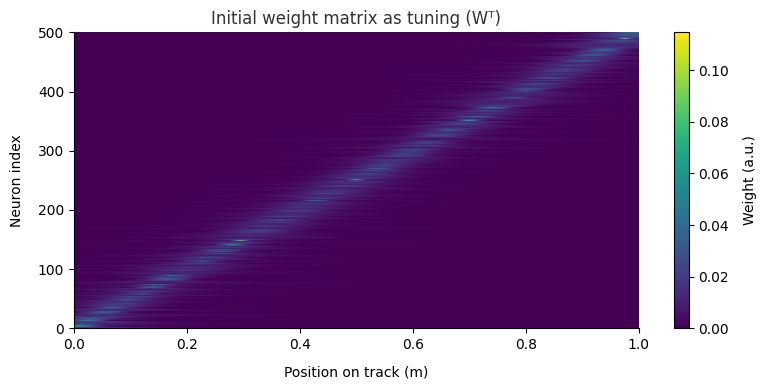

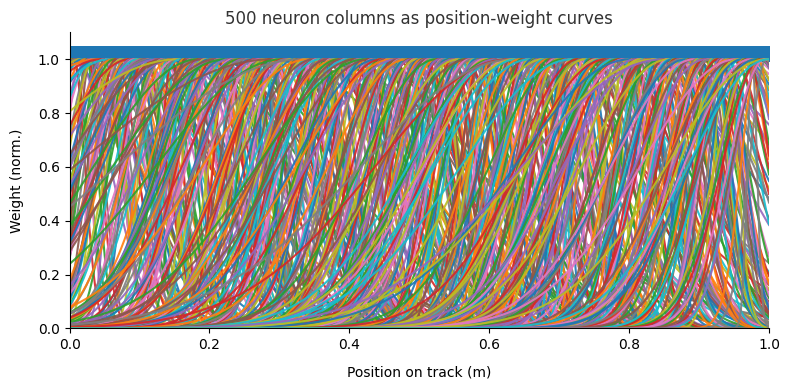

In [ ]:
def plot_W_init_heatmap(W, L=1.0, title="Weight matrix as tuning (Wᵀ)"):
    """
    Show W^T as a neuron × position heatmap so the x-axis is position (m),
    y-axis is neuron index, like your previous population heatmap.
    """
    M_inputs, N_neurons = W.shape  # current code: N×N, but works for M×N too
    x = np.linspace(0.0, L, M_inputs)

    plt.figure(figsize=(8, 4))
    # transpose so rows = neurons, columns = positions
    plt.imshow(W.T, aspect='auto', origin='lower',
               extent=[x[0], x[-1], 0, N_neurons])
    plt.colorbar(label="Weight (a.u.)")
    plt.xlabel("Position on track (m)")
    plt.ylabel("Neuron index")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_W_init_columns_as_curves(W, L=1.0, max_curves=20, normalize_each=True):
    """
    Plot a subset of neuron columns as curves over position (like tuning curves).
    Each curve is one column W[:, i] vs position. Optionally normalize each
    curve to its own max for readability.
    """
    M_inputs, N_neurons = W.shape
    x = np.linspace(0.0, L, M_inputs)
    k = min(max_curves, N_neurons)

    plt.figure(figsize=(8, 4))
    for i in range(k):
        y = W[:, i]
        if normalize_each and y.max() > 0:
            y = y / y.max()
        plt.plot(x, y, alpha=0.9)
    # mark approximate centers (argmax of each shown column)
    centers_idx = np.argmax(W[:, :k], axis=0)
    centers_x = x[centers_idx]
    plt.scatter(centers_x, np.ones(k)*1.02, marker='|', s=120)
    plt.ylim(0, 1.1 if normalize_each else None)
    plt.xlabel("Position on track (m)")
    plt.ylabel("Weight" + (" (norm.)" if normalize_each else " (a.u.)"))
    plt.title(f"{k} neuron columns as position-weight curves")
    plt.tight_layout()
    plt.show()

plot_W_init_heatmap(W_init, L=L, title="Initial weight matrix as tuning (Wᵀ)")
plot_W_init_columns_as_curves(W_init, L=L, max_curves=500)

Plotting 2459 edges (top 1%)


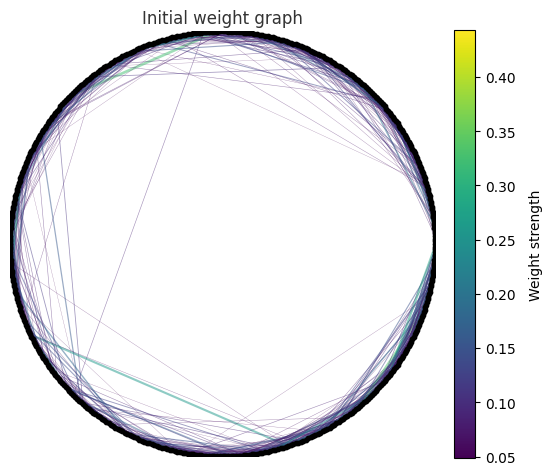

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def plot_weight_graph(W_matrix, top_percent=5, max_edges=2000,
                      node_size=10, title="Weight graph"):
    """
    W_matrix : (N, N) weight matrix at one time point.
    top_percent : keep only the top X% strongest (positive) weights.
    max_edges : hard cap on number of drawn edges.
    """

    W = W_matrix.copy()
    N = W.shape[0]

    # remove self-connections
    np.fill_diagonal(W, 0)

    # only positive weights for plotting
    positive = W[W > 0]
    if positive.size == 0:
        print("No positive weights to plot.")
        return

    # threshold: keep only top X% strongest weights
    thresh = np.percentile(positive, 100 - top_percent)
    mask = W >= thresh

    # get edge list (i, j) and corresponding weights
    idx_i, idx_j = np.where(mask)
    weights = W[idx_i, idx_j]
    print(f"Plotting {len(weights)} edges (top {top_percent}%)")
    # optional: limit to max_edges strongest edges
    if len(weights) > max_edges:
        order = np.argsort(weights)[-max_edges:]
        idx_i, idx_j = idx_i[order], idx_j[order]
        weights = weights[order]

    # node positions on a circle
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    xs = np.cos(angles)
    ys = np.sin(angles)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect("equal")
    ax.axis("off")

    # draw nodes
    ax.scatter(xs, ys, s=node_size, color="k", zorder=3)

    # normalise weights for colour / linewidth
    w_min, w_max = weights.min(), weights.max()
    norm = plt.Normalize(vmin=w_min, vmax=w_max)
    cmap = plt.cm.viridis

    # draw edges
    for i, j, w in zip(idx_i, idx_j, weights):
        x1, y1 = xs[i], ys[i]
        x2, y2 = xs[j], ys[j]
        lw = 0.2 + 2.5 * (w - w_min) / (w_max - w_min + 1e-9)
        ax.plot([x1, x2], [y1, y2],
                linewidth=lw,
                color=cmap(norm(w)),
                alpha=0.5,
                zorder=1)
    

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Weight strength")

    ax.set_title(title)
    plt.show()

# Example usage:
plot_weight_graph(W_baseline, top_percent=1, max_edges=10000,
                  node_size=10, title="Initial weight graph")

### Setup the excitability curves

In [5]:
def show_matrix(M, title="Matrix", xlabel="X", ylabel="Y", cmap="viridis"):
    """
    Quick display of a 2D matrix using imshow.
    Automatically handles numpy arrays and lists-of-lists.
    """
    M = np.asarray(M)

    plt.figure(figsize=(6, 4))
    im = plt.imshow(M, aspect='auto', interpolation='nearest', cmap=cmap)
    plt.colorbar(im)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def plot_exc_traces(exc, n_traces=100, alpha=0.05, linewidth=1.0,
                    title="Neuron Excitability Over Time",
                    xlabel="Time (hours)", ylabel="Excitability"):
    """
    Plots excitability traces for a set of neurons.
    
    Parameters:
        exc : 2D array (N neurons × T timepoints)
        n_traces : number of randomly selected neurons to plot
        alpha : transparency for each line (0-1)
        linewidth : width of each neuron trace
    """
    exc = np.asarray(exc)
    N, T = exc.shape

    # Select subset to prevent over-plotting
    if n_traces < N:
        idx = np.random.choice(N, size=n_traces, replace=False)
        data = exc[idx, :]
    else:
        data = exc

    time_axis = np.arange(T)

    plt.figure(figsize=(10, 5))

    for trace in data:
        plt.plot(time_axis, trace, alpha=alpha, linewidth=linewidth, color='black')

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_series(y, x=None, title="Series Plot", xlabel="Index", ylabel="Value", lw=2, alpha=1.0):
    """
    Plot a single 1D variable list or array.
    
    Args:
        y: list or 1D numpy array of values to plot
        x: optional x-axis values (same length as y). If None, uses index.
        title, xlabel, ylabel: labels for plot
        lw: line width
        alpha: line transparency
    """
    import numpy as np
    import matplotlib.pyplot as plt

    y = np.asarray(y)
    
    if x is None:
        x = np.arange(len(y))
    
    plt.figure(figsize=(6, 3.2))
    plt.plot(x, y, linewidth=lw, alpha=alpha)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


0
0 100 0 168
168
100 200 168 336
336
200 300 336 504
504
300 400 504 672
672
400 500 672 840
840
500 600 840 1008
(500, 840)


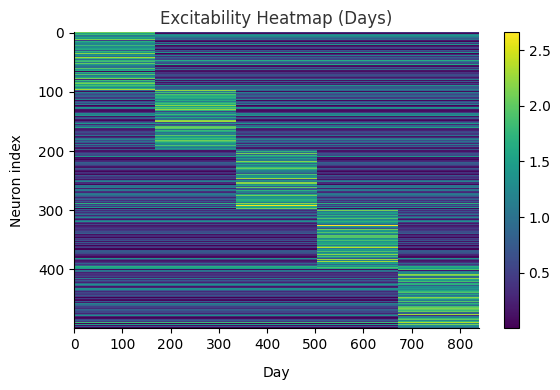

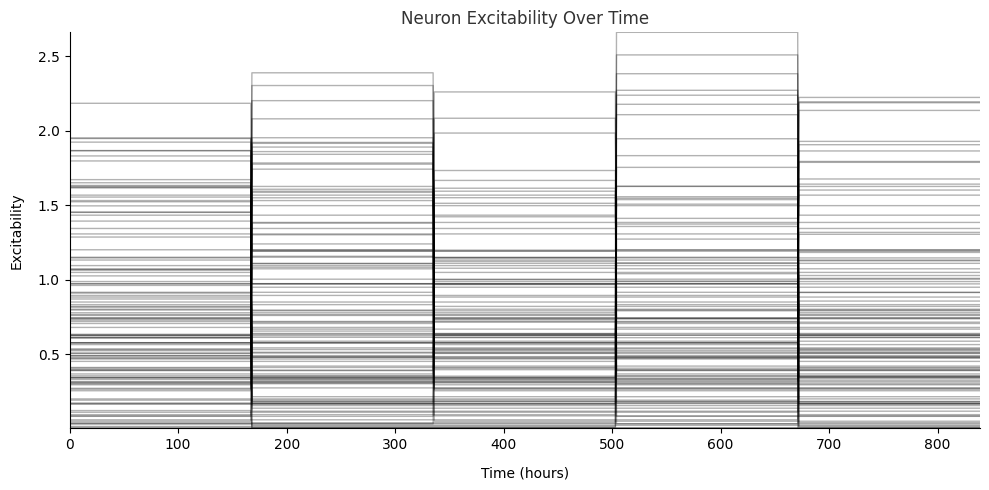

In [6]:
# --- Excitability schedule across days ---
# Uses circadian rhythm + slow cell-by-cell drift + spatial bump near x_stim

A = 0.6          # circadian amplitude
sigma = 0.15     # neuron-specific drift strength
alpha = 0.995    # temporal smoothness (higher = slower drift)

# Preferred positions for each neuron (same as used in your place fields)
positions = np.linspace(0, L, N, endpoint=False)

# Width of excitability bump (in track units)
bump_width = 0.12 * L   

exc = np.zeros((N, n_steps))

# Initial random neuron-specific offset
delta = rng.normal(0, sigma, size=N)

# for d in range(n_days):
#     # Circadian term: assume each "day" corresponds to a full 24h cycle
#     circ = A * np.sin(2 * np.pi * (d % 24) / 24.0 + d)
#     # Spatial excitability bump centered at x_stim
#     dist = np.abs(positions - x_stim)
#     dist = np.minimum(dist, L - dist)      # wrap around track
#     bump = np.exp(-0.5 * (dist / bump_width)**2)

#     # Combine: baseline + circadian + neuron-specific drift + bump
#     exc[:, d] = circ + delta + bump

#     # Update neuron-specific drift each day (slow wandering bias)
#     delta = alpha * delta + (1 - alpha) * rng.normal(0, sigma, size=N)

exc_baseline = abs(np.random.normal(0.5, 0.5, size=(N, 1)))
exc = np.tile(exc_baseline, (1, n_steps))
exc_elevated = abs(np.random.normal(1.5, 0.5, size=(N, 1)))
exc_elevated = np.tile(exc_elevated, (1, n_steps))
devs = 5
for i in range(0,devs+1):
    #print(i*N//devs)
    print(i* n_steps//(devs))
    start_N  = i*N//devs
    end_N = (i+1)* N//devs
    start_n =  i* n_steps//(devs)
    end_n = (i+1)* n_steps//(devs)
    print(start_N, end_N, start_n, end_n)
    exc[start_N:end_N, start_n:end_n] = exc_elevated[start_N:end_N, start_n:end_n]

print(np.shape(exc))
#exc[499:, :]
# Visualize
show_matrix(exc, title="Excitability Heatmap (Days)", xlabel="Day", ylabel="Neuron index")
plot_exc_traces(exc, n_traces=120, alpha=0.30) #0.08


### Run simulation

In [59]:
# --- State variables ---
r = np.zeros(N)        # firing rates of all N neurons at current time
W[:, :, 0] = W_baseline   # start from your prerun weights

step = 0
day_idx = 0
dt = 1
tau_r = 50.0
for t in tqdm(range(n_steps)):
    t = t
    # 1) Excitability at this time step (shape: N,)
    exc_t = exc[:, t]

    # 2) Choose current position on track.
    # For now: always stimulate at x_stim (deprivation-style).
    # Later you can change this to a random walk or trajectory.
    x = x_stim

    # 3) External input from position x
    #    Simple Gaussian place field centred at each neuron's preferred position.
    #    'vars' here is your lognormal place-field width per neuron.
    dist = np.abs(positions - x)
    I_ext = np.exp(-0.5 * (dist / vars)**2)       # shape: (N,)

    # 4) Recurrent input from other neurons
    W_t = W[:, :, t]                              # weights at time t
    recurrent = W_t @ r                           # shape: (N,)

    # 5) Total input + firing-rate update
    #    a = "propensity" steepness for tanh
    total_input = recurrent + I_ext + exc_t
    r = r + (dt / tau_r) * (-r + np.maximum(0, total_input))

    # 6) Hebbian + decay weight update
    #    ΔW_ij ∝ r_i r_j  -  decay * W_ij
    hebb_term  = hebb_scaling * np.outer(r, r)
    decay_term = rand_scaling * W_t               # acts like α W in your equation
    dW = hebb_term - decay_term

    W_new = W_t + learning_rate * dW       # Euler update for W

    if t % n_steps_per_norm == 0:
        normalisation(W_new)
        if t % (n_steps_per_norm * n_norm_per_day) == 0:
            day_idx = t // (n_steps_per_norm * n_norm_per_day)
            if day_idx < n_days:
                W_per_day[:, :, day_idx] = W_new
    W[:, :, t+1] = W_new
    # --- optional normalisation after each 'norm' block ---
    # e.g. L2-normalise rows or columns to stop runaway growth
   



 15%|█▌        | 130/840 [00:01<00:09, 71.39it/s]c:\Users\sctcl\place_cell_representational_drift\.venv\Lib\site-packages\numpy\_core\numeric.py:995: RuntimeWarning: overflow encountered in multiply
  return multiply(a.ravel()[:, newaxis], b.ravel()[newaxis, :], out)
C:\Users\sctcl\AppData\Local\Temp\ipykernel_20896\2021184439.py:38: RuntimeWarning: invalid value encountered in subtract
  dW = hebb_term - decay_term
100%|██████████| 840/840 [00:11<00:00, 74.01it/s]


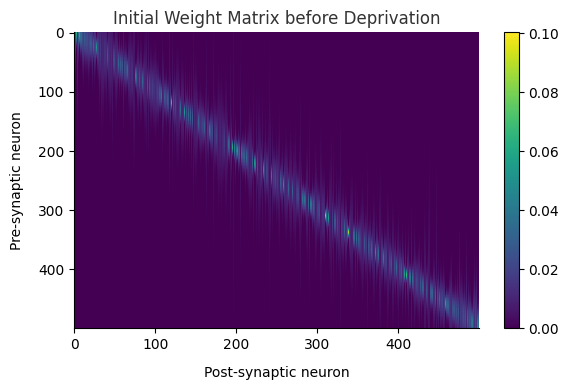

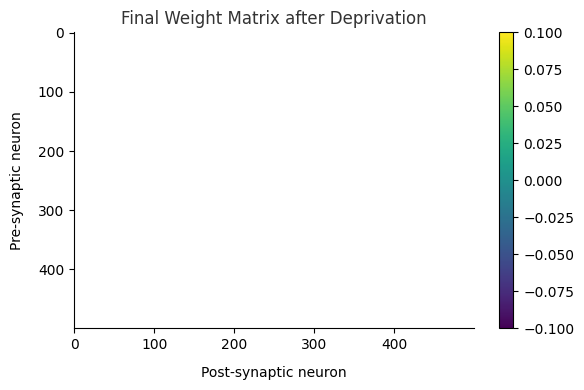

NaN percentage in W: 83.9477%
[[1.78303780e+21 1.54872789e+21 2.14384129e+21 ... 8.68656255e+20
  1.03787921e+21 3.46053910e+20]
 [1.54872789e+21 1.34520876e+21 1.86211801e+21 ... 7.54505693e+20
  9.01490971e+20 3.00578789e+20]
 [2.14384129e+21 1.86211801e+21 2.57765455e+21 ... 1.04443167e+21
  1.24789744e+21 4.16079044e+20]
 ...
 [8.68656255e+20 7.54505693e+20 1.04443167e+21 ... 4.23189958e+20
  5.05631607e+20 1.68589749e+20]
 [1.03787921e+21 9.01490971e+20 1.24789744e+21 ... 5.05631607e+20
  6.04133717e+20 2.01432723e+20]
 [3.46053910e+20 3.00578789e+20 4.16079044e+20 ... 1.68589749e+20
  2.01432723e+20 6.71625184e+19]]


In [64]:
# --- end of one day: store snapshot for analysis / drift plots ---
show_matrix(W[:, :, 0], title="Initial Weight Matrix before Deprivation",
            xlabel="Post-synaptic neuron", ylabel="Pre-synaptic neuron")
show_matrix(W[:, :, -1], title="Final Weight Matrix after Deprivation",
            xlabel="Post-synaptic neuron", ylabel="Pre-synaptic neuron")
nan_ratio = np.isnan(W).mean() * 100
print(f"NaN percentage in W: {nan_ratio:.4f}%")
print(W[:, :, 131])

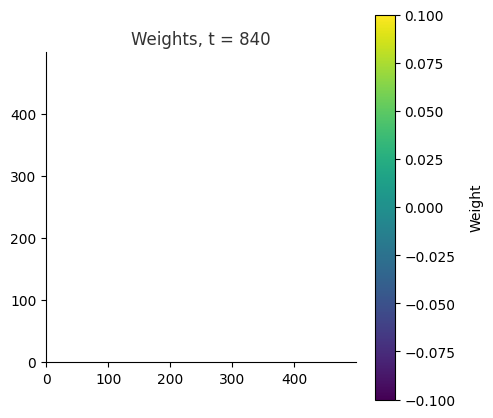

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# W shape: (N, N, n_steps+1)

N, _, T = W.shape      # T = n_steps + 1

# Optional: only show every k-th frame to keep it light
frame_step = 10        # e.g. 10 → use t = 0,10,20,...
frames = range(0, T, frame_step)

# Fix colour scale across time so you can compare frames
w_min = np.min(W)
w_max = np.max(W)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(W[:, :, 0], vmin=w_min, vmax=w_max, cmap="viridis", origin="lower")
ax.set_title("Weights, t = 0")
plt.colorbar(im, ax=ax, label="Weight")

def update(frame_idx):
    t = frame_idx
    im.set_data(W[:, :, t])
    ax.set_title(f"Weights, t = {t}")
    return [im]

ani = FuncAnimation(fig, update, frames=frames, interval=100, blit=True)

# Save if you like:
ani.save("weights_over_time.gif", writer="pillow")
plt.show()
